原图tensor shape=torch.Size([3, 1164, 1200]), dtype=torch.float32


/var/folders/pw/scm_l3mx0f39r4s0qn32p_s00000gn/T/ipykernel_9305/236105642.py:106: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current font.
  plt.tight_layout()
/var/folders/pw/scm_l3mx0f39r4s0qn32p_s00000gn/T/ipykernel_9305/236105642.py:106: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.
  plt.tight_layout()
/var/folders/pw/scm_l3mx0f39r4s0qn32p_s00000gn/T/ipykernel_9305/236105642.py:106: UserWarning: Glyph 20142 (\N{CJK UNIFIED IDEOGRAPH-4EAE}) missing from current font.
  plt.tight_layout()
/var/folders/pw/scm_l3mx0f39r4s0qn32p_s00000gn/T/ipykernel_9305/236105642.py:106: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  plt.tight_layout()
/var/folders/pw/scm_l3mx0f39r4s0qn32p_s00000gn/T/ipykernel_9305/236105642.py:106: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from current font.
  plt.tight_layout()
/var/folders/pw/scm_l3mx0f39r4s0qn32p_s00000gn/T/ipykernel_9

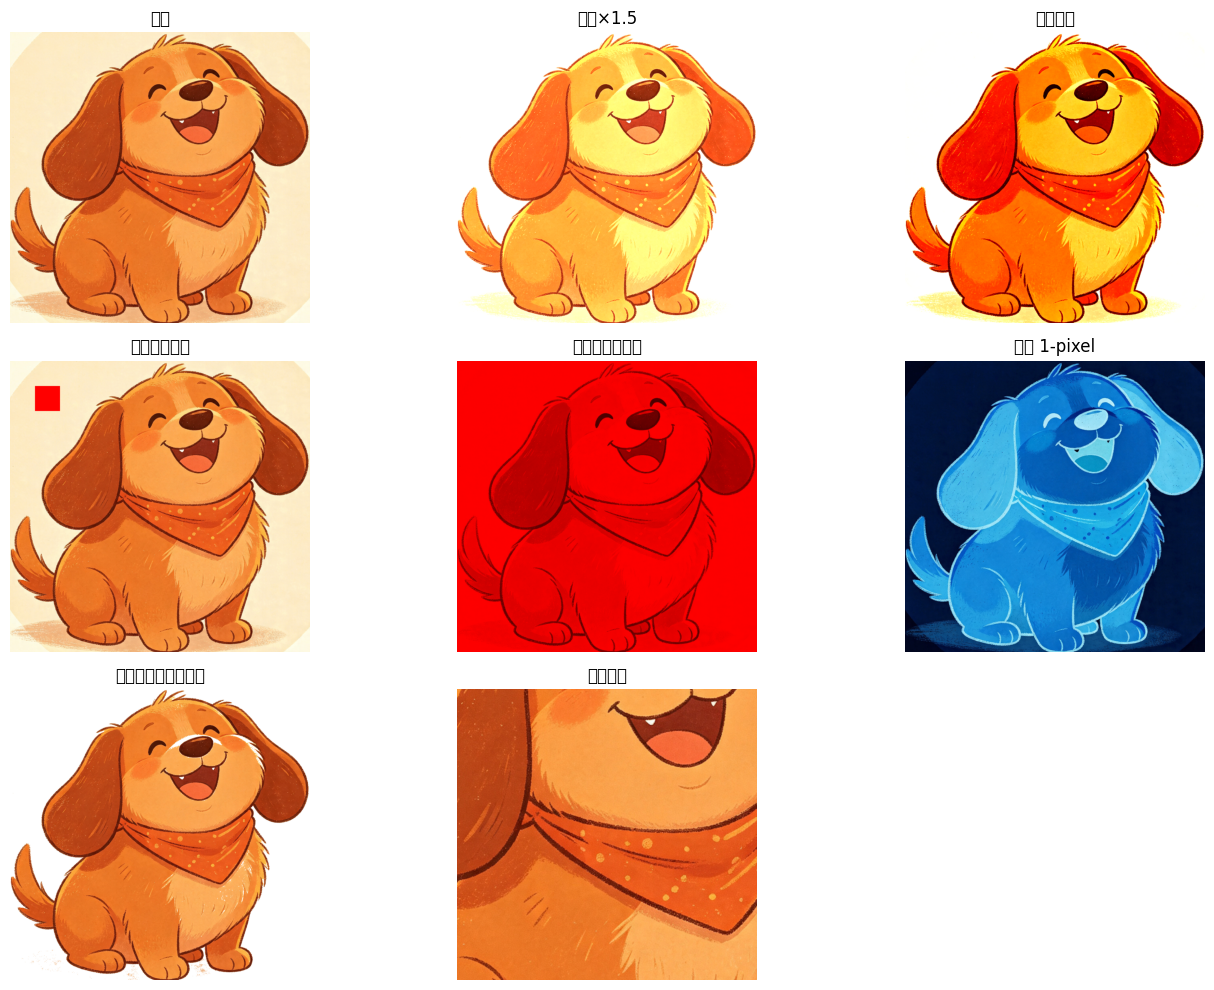

已保存亮度增强图片 bright_out.jpg


In [5]:
from PIL import Image
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

# ========= 修改为你的本地图片路径 =========
IMAGE_PATH = "./data/dog.png"

# 读取图片，强制丢弃透明通道，转为RGB（解决RGBA报错）
pil_img = Image.open(IMAGE_PATH).convert("RGB")
# pil_img = pil_img.convert("L")  # 打开这行变成灰度图

# 转成张量 [C,H,W] float32 0~1
transform = transforms.Compose([transforms.ToTensor()])
img_tensor = transform(pil_img)
C, H, W = img_tensor.shape

print(f"原图tensor shape={img_tensor.shape}, dtype={img_tensor.dtype}")

# ---------------------- 工具函数：张量转成numpy用于绘图 ----------------------
def tensor_to_np(t):
    arr = t.detach().cpu().numpy()
    c, h, w = arr.shape
    if c == 1:
        return arr.squeeze(0)
    else:
        return np.transpose(arr, (1, 2, 0))

# ---------------------- 实验1：整体调亮度（全部像素乘系数） ----------------------
img_bright = img_tensor * 1.5   # 放大亮度；注意会超过1.0
img_bright = torch.clamp(img_bright, 0.0, 1.0) # 限制在0‑1，截断溢出

# ---------------------- 实验2：调对比度：以0.5为中心点缩放 ----------------------
img_contrast = (img_tensor - 0.5) * 2.0 + 0.5
img_contrast = torch.clamp(img_contrast, 0.0, 1.0)

# ---------------------- 实验3：把图片某一块区域强行改成红色（修改像素） ----------------------
img_red_block = img_tensor.clone()
# [C,H,W]，取H方向 100:200，W方向100:200
img_red_block[0, 100:200, 100:200] = 1.0   # R通道=1
img_red_block[1, 100:200, 100:200] = 0.0   # G=0
img_red_block[2, 100:200, 100:200] = 0.0   # B=0

# ---------------------- 实验4：通道分离，把G、B置0，只保留红色通道 ----------------------
img_only_red = img_tensor.clone()
img_only_red[1,:,:] = 0.0
img_only_red[2,:,:] = 0.0

# ---------------------- 实验5：图片取反（负片， 1‑pixel） ----------------------
img_invert = 1.0 - img_tensor

# ---------------------- 实验6：布尔掩码，把偏亮的像素置为白色 ----------------------
img_mask = img_tensor.clone()
# 对RGB图，取三个通道均值作为亮度
brightness = img_mask.mean(dim=0)  # shape [H,W]
mask = brightness > 0.7   # bool掩码，亮于0.7的位置为True
img_mask[:, mask] = 1.0   # 满足条件全部改成白色

# ---------------------- 实验7：裁剪：取出中间一块子图 ----------------------
img_crop = img_tensor[:, H//4:H*3//4, W//4:W*3//4]

# ---------------------- 绘图展示所有结果 ----------------------
plt.figure(figsize=(14,10))

plt.subplot(3,3,1)
plt.title("原图")
plt.imshow(tensor_to_np(img_tensor))
plt.axis("off")

plt.subplot(3,3,2)
plt.title("亮度×1.5")
plt.imshow(tensor_to_np(img_bright))
plt.axis("off")

plt.subplot(3,3,3)
plt.title("高对比度")
plt.imshow(tensor_to_np(img_contrast))
plt.axis("off")

plt.subplot(3,3,4)
plt.title("局部红色方块")
plt.imshow(tensor_to_np(img_red_block))
plt.axis("off")

plt.subplot(3,3,5)
plt.title("只保留红色通道")
plt.imshow(tensor_to_np(img_only_red))
plt.axis("off")

plt.subplot(3,3,6)
plt.title("负片 1‑pixel")
plt.imshow(tensor_to_np(img_invert))
plt.axis("off")

plt.subplot(3,3,7)
plt.title("掩码：高亮区域变白")
plt.imshow(tensor_to_np(img_mask))
plt.axis("off")

plt.subplot(3,3,8)
plt.title("中心裁剪")
plt.imshow(tensor_to_np(img_crop))
plt.axis("off")

plt.tight_layout()
plt.show()

# ---------------------- 实验8：张量再保存回本地图片 ----------------------
from torchvision import transforms as T
to_pil = T.ToPILImage()
pil_out = to_pil(img_bright)
# jpg不支持透明，已经convert("RGB")，现在可以存jpg；也可以存png
pil_out.save("./bright_out.jpg")
# pil_out.save("./bright_out.png")
print("已保存亮度增强图片 bright_out.jpg")
